In [5]:
using Plots
using Plots.PlotMeasures
using HDF5

### Initial Parameters ###

In [6]:
N = 15 #Number of lattice sites per dimension
d = 1 #Number of spatial dimensions
Dim = 10 #Truncated local Hilbert space dimension
a = 1.0 #Lattice spacing

n_0 = round(Int, ((N-1)/2)) #Index of the point at the center of the lattice (0-based indexing).

mass = 1.0
m0 = 1 #Basis frequency
l = 0.1; #phi^4 coupling strength

### EEC Parameters ###

In [7]:
#Coordinate position of the detectors (as tuples). (The lattice index is given by (n_0+1) + the ith component)
r1_list = [1,2,3,4,5]
#Measurement time
t1i = 0.0
t2i = 0.0
t1f = 3.0
t2f = 3.0
dt = 0.2
t1_range = range(0, t1f, step=dt)
t2_range = range(0, t2f, step=dt)

0.0:0.2:3.0

### Compute the EEC ###

In [8]:
#"Integrate" the correlators over t1 and t2
function calcEEC(r1, r2)
    EEC = 0
    data = h5open("Z:/Energy Correlator/1d_EEC_data/EEC,N=$N,a=$a,l=$l,m=$mass,r1=$r1,r2=$r2,t1i=$t1i,t1f=$t1f,t2i=$t2i,t2f=$t2f,dt=$dt", "r")
    for i in 1:length(t1_range)
        for j in 1:length(t2_range)
            ME = data["MaEl"][i,j]
            EEC += dt^2 * r1^(d-1) * r2^(d-1) * ME
        end
    end
    close(data)
    return EEC
end

EECs = [calcEEC(r1, -1 .* r1) for r1 in r1_list]

5-element Vector{ComplexF64}:
 0.0007697410765306209 + 7.865264189942684e-7im
 1.5846023542767165e-6 + 3.3189194210210517e-9im
 4.7624034034749065e-8 - 1.9603156359624018e-8im
 -1.411637341189205e-8 + 3.089069164090855e-8im
 -4.202127766894571e-6 - 2.1749965398933996e-7im

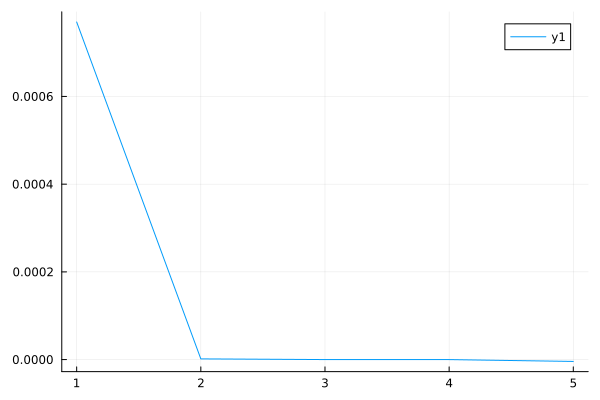

In [10]:
plot(r1_list, real(EECs))